# Laboratório: Métricas de Avaliação em ML, NLP e LLMs

**Disciplina:** Fundamentos de IA  
**Prof.:** Luiz Eduardo S. Oliveira  
**Objetivo:** Praticar o uso de métricas clássicas de aprendizagem de máquina, métricas de PLN e métricas para LLMs

---

## Parte 1: Métricas Clássicas de Classificação

Nesta seção, você irá trabalhar com métricas fundamentais: Acurácia, Precision, Recall, F1-Score, Matriz de Confusão e Curva ROC.

In [ ]:
# Instalação de bibliotecas necessárias
!pip install scikit-learn matplotlib seaborn numpy pandas transformers torch nltk rouge-score bert-score openai --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

# Configuração para gráficos mais bonitos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Exercício 1.1: Dataset Balanceado

Vamos criar um dataset sintético balanceado e calcular as métricas básicas.

In [3]:
# Criando dataset balanceado
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                          n_redundant=5, n_classes=2, weights=[0.5, 0.5],
                          random_state=42)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinando modelo simples
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Predições
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Dataset Balanceado - Distribuição das classes:")
print(f"Classe 0: {sum(y_test == 0)} amostras")
print(f"Classe 1: {sum(y_test == 1)} amostras")

Dataset Balanceado - Distribuição das classes:
Classe 0: 160 amostras
Classe 1: 140 amostras


/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encou

**TAREFA:** Calcule e interprete as seguintes métricas:

In [4]:
# TODO: Calcule as métricas
acuracia = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MÉTRICAS - DATASET BALANCEADO")
print("=" * 50)
print(f"Acurácia:  {acuracia:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("=" * 50)

# TODO: Gere o Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

MÉTRICAS - DATASET BALANCEADO
Acurácia:  0.8200
Precision: 0.7945
Recall:    0.8286
F1-Score:  0.8112

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       160
           1       0.79      0.83      0.81       140

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300



**QUESTÃO 1.1:** Por que a acurácia é uma boa métrica para este dataset balanceado?

*Sua resposta aqui:*

---

### Exercício 1.2: Dataset Desbalanceado

Agora vamos trabalhar com um dataset desbalanceado (99% classe negativa, 1% classe positiva) - similar ao exemplo dos slides.

In [5]:
# Criando dataset desbalanceado (1% positivos)
X_imb, y_imb = make_classification(n_samples=1000, n_features=20, n_informative=15,
                                   n_redundant=5, n_classes=2, weights=[0.99, 0.01],
                                   flip_y=0.1, random_state=42)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42
)

# Modelo que prediz sempre a classe majoritária
y_pred_naive = np.zeros_like(y_test_imb)  # Sempre prediz classe 0

print("Dataset Desbalanceado - Distribuição das classes:")
print(f"Classe 0: {sum(y_test_imb == 0)} amostras ({100*sum(y_test_imb==0)/len(y_test_imb):.1f}%)")
print(f"Classe 1: {sum(y_test_imb == 1)} amostras ({100*sum(y_test_imb==1)/len(y_test_imb):.1f}%)")

Dataset Desbalanceado - Distribuição das classes:
Classe 0: 282 amostras (94.0%)
Classe 1: 18 amostras (6.0%)


In [6]:
# TODO: Calcule as métricas para o classificador "naive"
acuracia_naive = accuracy_score(y_test_imb, y_pred_naive)
precision_naive = precision_score(y_test_imb, y_pred_naive, zero_division=0)
recall_naive = recall_score(y_test_imb, y_pred_naive, zero_division=0)
f1_naive = f1_score(y_test_imb, y_pred_naive, zero_division=0)

print("=" * 50)
print("CLASSIFICADOR NAIVE (sempre prediz classe 0)")
print("=" * 50)
print(f"Acurácia:  {acuracia_naive:.4f}")
print(f"Precision: {precision_naive:.4f}")
print(f"Recall:    {recall_naive:.4f}")
print(f"F1-Score:  {f1_naive:.4f}")
print("=" * 50)

CLASSIFICADOR NAIVE (sempre prediz classe 0)
Acurácia:  0.9400
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000


**QUESTÃO 1.2:** Por que a acurácia é enganosa neste caso? Qual métrica seria mais apropriada?

*Sua resposta aqui:*

---

### Exercício 1.3: Matriz de Confusão

Visualize a matriz de confusão para entender melhor os erros do modelo.

/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encou

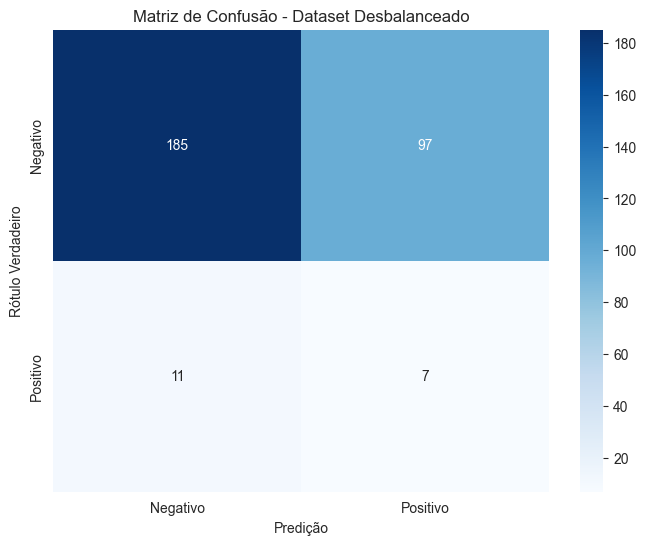


True Negatives (TN):  185
False Positives (FP): 97
False Negatives (FN): 11
True Positives (TP):  7


In [7]:
# Treinando um modelo real no dataset desbalanceado
model_imb = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_imb.fit(X_train_imb, y_train_imb)
y_pred_imb = model_imb.predict(X_test_imb)

# TODO: Crie a matriz de confusão
cm = confusion_matrix(y_test_imb, y_pred_imb)

# Visualização
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Predição')
plt.title('Matriz de Confusão - Dataset Desbalanceado')
plt.show()

# Extraindo TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print(f"\nTrue Negatives (TN):  {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP):  {TP}")

### Exercício 1.4: Curva ROC e AUC

A curva ROC mostra o trade-off entre True Positive Rate e False Positive Rate.

/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lesoliveira/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


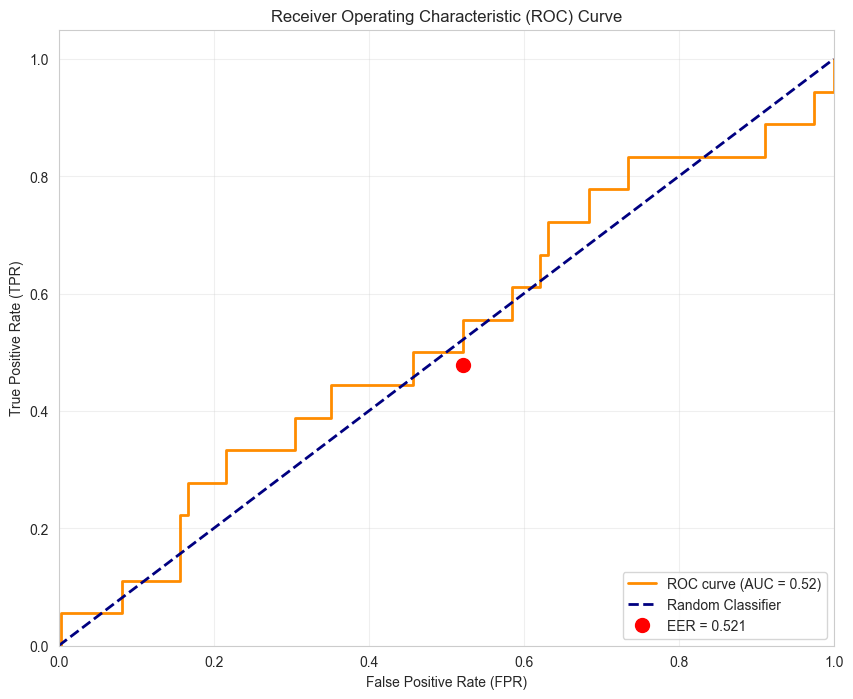


Area Under Curve (AUC): 0.5246
Equal Error Rate (EER): 0.5213


In [8]:
# TODO: Calcule a curva ROC
y_pred_proba_imb = model_imb.predict_proba(X_test_imb)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_imb, y_pred_proba_imb)
roc_auc = auc(fpr, tpr)

# Plotando a curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Calculando e plotando o EER
eer_threshold = np.nanargmin(np.abs(fpr - (1 - tpr)))
eer_value = fpr[eer_threshold]
plt.plot(eer_value, 1-eer_value, 'ro', markersize=10, label=f'EER = {eer_value:.3f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nArea Under Curve (AUC): {roc_auc:.4f}")
print(f"Equal Error Rate (EER): {eer_value:.4f}")

**QUESTÃO 1.4:** O que significa ter um AUC próximo de 1.0? E próximo de 0.5?

*Sua resposta aqui:*

---

## Parte 2: Métricas de PLN (Geração de Texto)

Nesta seção, você irá explorar métricas para avaliação de texto gerado: BLEU, ROUGE e METEOR.

In [9]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

# Download de recursos necessários
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

### Exercício 2.1: BLEU Score

BLEU mede a precisão de n-gramas entre o texto gerado e a referência.

In [10]:
# Exemplos dos slides
referencia = "O gato está sobre o tapete"
modelo_A = "O gato está no tapete"
modelo_B = "Um felino repousa sobre o carpete"

# Tokenização
ref_tokens = referencia.lower().split()
modelo_A_tokens = modelo_A.lower().split()
modelo_B_tokens = modelo_B.lower().split()

# Calculando BLEU
smoothing = SmoothingFunction().method1
bleu_A = sentence_bleu([ref_tokens], modelo_A_tokens, smoothing_function=smoothing)
bleu_B = sentence_bleu([ref_tokens], modelo_B_tokens, smoothing_function=smoothing)

print("=" * 60)
print("BLEU SCORE")
print("=" * 60)
print(f"Referência: {referencia}")
print(f"Modelo A:   {modelo_A}")
print(f"  BLEU Score: {bleu_A:.4f}")
print(f"\nModelo B:   {modelo_B}")
print(f"  BLEU Score: {bleu_B:.4f}")
print("=" * 60)

BLEU SCORE
Referência: O gato está sobre o tapete
Modelo A:   O gato está no tapete
  BLEU Score: 0.2339

Modelo B:   Um felino repousa sobre o carpete
  BLEU Score: 0.0863


**TAREFA 2.1:** Crie mais dois modelos de resposta e calcule seus BLEU scores. Um deve ter BLEU alto e outro BLEU baixo.

In [ ]:
# TODO: Crie modelo_C (com BLEU alto) e modelo_D (com BLEU baixo)
modelo_C = ""  # Sua resposta
modelo_D = ""  # Sua resposta

# TODO: Calcule os BLEU scores
# Seu código aqui

### Exercício 2.2: ROUGE Score

ROUGE mede o recall - quanto do conteúdo esperado apareceu no texto gerado.

In [11]:
# Exemplo dos slides
referencia_rouge = "O modelo foi treinado com dados públicos e privados"
modelo_rouge_A = "modelo foi treinado com dados públicos"

# Calculando ROUGE
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
scores = scorer.score(referencia_rouge, modelo_rouge_A)

print("=" * 60)
print("ROUGE SCORE")
print("=" * 60)
print(f"Referência: {referencia_rouge}")
print(f"Modelo A:   {modelo_rouge_A}")
print(f"\nROUGE-1 (unigrams):")
print(f"  Precision: {scores['rouge1'].precision:.4f}")
print(f"  Recall:    {scores['rouge1'].recall:.4f}")
print(f"  F1:        {scores['rouge1'].fmeasure:.4f}")
print(f"\nROUGE-2 (bigrams):")
print(f"  Precision: {scores['rouge2'].precision:.4f}")
print(f"  Recall:    {scores['rouge2'].recall:.4f}")
print(f"  F1:        {scores['rouge2'].fmeasure:.4f}")
print(f"\nROUGE-L (longest common subsequence):")
print(f"  Precision: {scores['rougeL'].precision:.4f}")
print(f"  Recall:    {scores['rougeL'].recall:.4f}")
print(f"  F1:        {scores['rougeL'].fmeasure:.4f}")
print("=" * 60)

ROUGE SCORE
Referência: O modelo foi treinado com dados públicos e privados
Modelo A:   modelo foi treinado com dados públicos

ROUGE-1 (unigrams):
  Precision: 1.0000
  Recall:    0.7000
  F1:        0.8235

ROUGE-2 (bigrams):
  Precision: 1.0000
  Recall:    0.6667
  F1:        0.8000

ROUGE-L (longest common subsequence):
  Precision: 1.0000
  Recall:    0.7000
  F1:        0.8235


**QUESTÃO 2.2:** Por que o ROUGE foca em recall enquanto BLEU foca em precision?

*Sua resposta aqui:*

---

### Exercício 2.3: METEOR Score

METEOR usa correspondência exata, stemming e sinônimos para avaliar similaridade.

In [12]:
# TODO: Calcule METEOR para os mesmos exemplos
meteor_A = meteor_score([ref_tokens], modelo_A_tokens)
meteor_B = meteor_score([ref_tokens], modelo_B_tokens)

print("=" * 60)
print("METEOR SCORE")
print("=" * 60)
print(f"Referência: {referencia}")
print(f"Modelo A:   {modelo_A}")
print(f"  METEOR Score: {meteor_A:.4f}")
print(f"\nModelo B:   {modelo_B}")
print(f"  METEOR Score: {meteor_B:.4f}")
print("=" * 60)

METEOR SCORE
Referência: O gato está sobre o tapete
Modelo A:   O gato está no tapete
  METEOR Score: 0.5350

Modelo B:   Um felino repousa sobre o carpete
  METEOR Score: 0.3125


**QUESTÃO 2.3:** Compare os scores BLEU e METEOR para o Modelo B. Por que o METEOR é mais alto?

*Sua resposta aqui:*

---

## Parte 3: Métricas para LLMs

Nesta seção, você irá trabalhar com métricas semânticas modernas: BERTScore e simulação de Perplexity.

### Exercício 3.1: BERTScore

BERTScore mede similaridade semântica usando embeddings contextualizados.

In [13]:
from bert_score import score

# Usando os mesmos exemplos
referencias = [referencia, referencia]
candidatos = [modelo_A, modelo_B]

# Calculando BERTScore
P, R, F1 = score(candidatos, referencias, lang='pt', verbose=False)

print("=" * 60)
print("BERTSCORE")
print("=" * 60)
print(f"Referência: {referencia}")
print(f"\nModelo A:   {modelo_A}")
print(f"  Precision: {P[0]:.4f}")
print(f"  Recall:    {R[0]:.4f}")
print(f"  F1:        {F1[0]:.4f}")
print(f"\nModelo B:   {modelo_B}")
print(f"  Precision: {P[1]:.4f}")
print(f"  Recall:    {R[1]:.4f}")
print(f"  F1:        {F1[1]:.4f}")
print("=" * 60)

BERTSCORE
Referência: O gato está sobre o tapete

Modelo A:   O gato está no tapete
  Precision: 0.9335
  Recall:    0.9163
  F1:        0.9248

Modelo B:   Um felino repousa sobre o carpete
  Precision: 0.8208
  Recall:    0.8494
  F1:        0.8349


**QUESTÃO 3.1:** Compare BLEU vs BERTScore para o Modelo B. O que você observa?

*Sua resposta aqui:*

---

### Exercício 3.2: Comparação de Todas as Métricas

Vamos comparar todas as métricas lado a lado.

In [14]:
# Criando um DataFrame comparativo
resultados = pd.DataFrame({
    'Modelo': ['Modelo A', 'Modelo B'],
    'Texto': [modelo_A, modelo_B],
    'BLEU': [bleu_A, bleu_B],
    'METEOR': [meteor_A, meteor_B],
    'BERTScore F1': [F1[0].item(), F1[1].item()]
})

print("\n" + "=" * 80)
print("COMPARAÇÃO DE TODAS AS MÉTRICAS")
print("=" * 80)
print(f"\nReferência: {referencia}\n")
print(resultados.to_string(index=False))
print("=" * 80)


COMPARAÇÃO DE TODAS AS MÉTRICAS

Referência: O gato está sobre o tapete

  Modelo                             Texto     BLEU   METEOR  BERTScore F1
Modelo A             O gato está no tapete 0.233947 0.534958      0.924808
Modelo B Um felino repousa sobre o carpete 0.086334 0.312500      0.834878


### Exercício 3.3: Perplexidade (Conceitual)

A perplexidade mede a "confusão" do modelo ao prever o próximo token.

In [15]:
# Simulação conceitual de perplexidade
# PPL = exp(cross_entropy)

# Exemplo: modelo confiante vs incerto
import math

# Modelo confiante: alta probabilidade para o token correto
prob_confiante = [0.8, 0.1, 0.05, 0.05]  # probabilidades para 4 possíveis tokens
# Modelo incerto: probabilidades mais uniformes
prob_incerto = [0.3, 0.25, 0.25, 0.2]

def calcular_perplexidade(probs):
    """Calcula perplexidade baseada em distribuição de probabilidades"""
    entropy = -sum([p * math.log(p) if p > 0 else 0 for p in probs])
    return math.exp(entropy)

ppl_confiante = calcular_perplexidade(prob_confiante)
ppl_incerto = calcular_perplexidade(prob_incerto)

print("=" * 60)
print("PERPLEXIDADE (PPL)")
print("=" * 60)
print(f"Modelo Confiante:")
print(f"  Probabilidades: {prob_confiante}")
print(f"  Perplexidade:   {ppl_confiante:.2f}")
print(f"\nModelo Incerto:")
print(f"  Probabilidades: {prob_incerto}")
print(f"  Perplexidade:   {ppl_incerto:.2f}")
print("\nInterpretação:")
print(f"  PPL baixa = modelo mais confiante")
print(f"  PPL alta  = modelo mais incerto")
print("=" * 60)

PERPLEXIDADE (PPL)
Modelo Confiante:
  Probabilidades: [0.8, 0.1, 0.05, 0.05]
  Perplexidade:   2.03

Modelo Incerto:
  Probabilidades: [0.3, 0.25, 0.25, 0.2]
  Perplexidade:   3.96

Interpretação:
  PPL baixa = modelo mais confiante
  PPL alta  = modelo mais incerto


## Parte 4: Exercícios Práticos

### Exercício Final: Avaliação Completa de um Sistema de Resumos

In [16]:
# Dataset de exemplo: artigos e seus resumos
dados_resumos = [
    {
        'original': "A inteligência artificial está transformando diversos setores da economia. "
                   "Empresas estão investindo bilhões em pesquisa e desenvolvimento de IA. "
                   "Os avanços em deep learning e processamento de linguagem natural são particularmente notáveis.",
        'referencia': "IA está transformando a economia com grandes investimentos em pesquisa, especialmente em deep learning e PLN.",
        'modelo_1': "Inteligência artificial transforma economia. Investimentos em IA crescem. Deep learning avança.",
        'modelo_2': "A IA está mudando vários setores econômicos através de bilhões investidos em pesquisa e desenvolvimento."
    },
    {
        'original': "O aquecimento global é um dos maiores desafios da humanidade. "
                   "As temperaturas médias globais aumentaram 1.1°C desde a era pré-industrial. "
                   "Cientistas alertam para a urgência de reduzir emissões de gases de efeito estufa.",
        'referencia': "Aquecimento global é desafio crítico com temperaturas 1.1°C mais altas, exigindo redução urgente de emissões.",
        'modelo_1': "Aquecimento global é grande desafio. Temperatura subiu 1.1°C. Precisamos reduzir emissões urgentemente.",
        'modelo_2': "O planeta enfrenta desafio climático com aumento de temperatura e necessidade de cortar emissões de carbono."
    }
]

print("Dataset de Resumos criado com sucesso!")
print(f"Total de exemplos: {len(dados_resumos)}")

Dataset de Resumos criado com sucesso!
Total de exemplos: 2


**TAREFA FINAL:** Para cada par de modelo/referência, calcule:
1. BLEU Score
2. ROUGE-1, ROUGE-2 e ROUGE-L
3. BERTScore
4. Determine qual modelo é melhor e justifique

In [17]:
# TODO: Complete esta função
def avaliar_resumo(referencia, candidato):
    """Avalia um resumo usando múltiplas métricas"""
    resultados = {}
    
    # BLEU
    ref_tokens = referencia.lower().split()
    cand_tokens = candidato.lower().split()
    smoothing = SmoothingFunction().method1
    resultados['BLEU'] = sentence_bleu([ref_tokens], cand_tokens, smoothing_function=smoothing)
    
    # ROUGE
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = scorer.score(referencia, candidato)
    resultados['ROUGE-1'] = rouge_scores['rouge1'].fmeasure
    resultados['ROUGE-2'] = rouge_scores['rouge2'].fmeasure
    resultados['ROUGE-L'] = rouge_scores['rougeL'].fmeasure
    
    # BERTScore
    P, R, F1 = score([candidato], [referencia], lang='pt', verbose=False)
    resultados['BERTScore'] = F1[0].item()
    
    return resultados

# Avaliando todos os modelos
for i, exemplo in enumerate(dados_resumos):
    print(f"\n{'='*80}")
    print(f"EXEMPLO {i+1}")
    print(f"{'='*80}")
    print(f"Original: {exemplo['original'][:100]}...")
    print(f"\nReferência: {exemplo['referencia']}")
    
    for modelo_nome in ['modelo_1', 'modelo_2']:
        print(f"\n{modelo_nome.upper()}:")
        print(f"Texto: {exemplo[modelo_nome]}")
        
        metricas = avaliar_resumo(exemplo['referencia'], exemplo[modelo_nome])
        print("\nMétricas:")
        for metrica, valor in metricas.items():
            print(f"  {metrica:12s}: {valor:.4f}")


EXEMPLO 1
Original: A inteligência artificial está transformando diversos setores da economia. Empresas estão investindo...

Referência: IA está transformando a economia com grandes investimentos em pesquisa, especialmente em deep learning e PLN.

MODELO_1:
Texto: Inteligência artificial transforma economia. Investimentos em IA crescem. Deep learning avança.

Métricas:
  BLEU        : 0.0378
  ROUGE-1     : 0.4828
  ROUGE-2     : 0.1481
  ROUGE-L     : 0.3448
  BERTScore   : 0.7317

MODELO_2:
Texto: A IA está mudando vários setores econômicos através de bilhões investidos em pesquisa e desenvolvimento.

Métricas:
  BLEU        : 0.0329
  ROUGE-1     : 0.3429
  ROUGE-2     : 0.1212
  ROUGE-L     : 0.2857
  BERTScore   : 0.8266

EXEMPLO 2
Original: O aquecimento global é um dos maiores desafios da humanidade. As temperaturas médias globais aumenta...

Referência: Aquecimento global é desafio crítico com temperaturas 1.1°C mais altas, exigindo redução urgente de emissões.

MODELO_1:
Text

**QUESTÃO FINAL:** 
1. Qual modelo teve melhor desempenho geral?
2. Houve discrepância entre as métricas lexicais (BLEU/ROUGE) e semânticas (BERTScore)?
3. Qual métrica você consideraria mais importante para avaliar resumos? Por quê?

*Suas respostas aqui:*

---

## Conclusão

Neste laboratório você explorou:

**Métricas Clássicas de ML:**
- Acurácia, Precision, Recall, F1-Score
- Matriz de Confusão
- Curva ROC e AUC
- Problemas com datasets desbalanceados

**Métricas de PLN:**
- BLEU (precision de n-gramas)
- ROUGE (recall de n-gramas)
- METEOR (com stemming e sinônimos)

**Métricas para LLMs:**
- BERTScore (similaridade semântica)
- Perplexidade (conceitual)
- Trade-offs entre métricas lexicais e semânticas

### Próximos Passos:
1. Explore outras métricas como BLEURT
2. Implemente um sistema LLM-as-a-Judge
3. Experimente com modelos de linguagem reais usando HuggingFace
4. Investigue métricas de raciocínio (Pass@k) para coding tasks